In [ ]:
import pandas as Dimen_ReductPn
import warnings as Dimen_ReductWn
Dimen_ReductWn.filterwarnings("ignore")

Runtime crashed after vectorization. So taking 2000 data for implementation without dimensionality reduction.

In [ ]:
Dimen_Reduct = Dimen_ReductPn.read_csv('TextData_DimensionalityReduction.csv',nrows=2000)

In [ ]:
Dimen_Reduct['category'].value_counts()

,count
category,
POLITICS,713
ENTERTAINMENT,479
COMEDY,133
WORLD NEWS,116
BLACK VOICES,105
QUEER VOICES,97
MEDIA,62
CRIME,59
WEIRD NEWS,57


In [ ]:
Dimen_top3_catgory = Dimen_Reduct['category'].value_counts().nlargest(3).index
Dimen_Reduct = Dimen_Reduct[Dimen_Reduct['category'].isin(Dimen_top3_catgory)]

In [ ]:
from sklearn.preprocessing import LabelEncoder as DimenRedctEn
Dimen_Reduct['category'].value_counts()
DimenRedctenc = DimenRedctEn()
Dimen_Reduct['category'] = DimenRedctenc.fit_transform(Dimen_Reduct['category'])

In [ ]:
Dimen_Reduct

,short_description,category
1,course song,1
2,actor longtime girlfriend anna eberstein tied ...,1
3,actor gives dems ass kicking fighting hard eno...,1
4,dietland actress said using bags really cathar...,1
5,right equate horrific incidents sexual assault...,1
...,...,...
1993,know first instinct hate,0
1994,purple one estate released song previously uns...,1
1996,using words president may understand,0
1997,late show host finds hidden meaning trump tweet,0


In [ ]:
Dimen_Reduct['category'].value_counts()

,count
category,
2,713
1,479
0,133


In [ ]:
DimenRedctXa = Dimen_Reduct.drop(['category'], axis=1)
DimenRedctYa = Dimen_Reduct['category']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer as DimenRedctTfdVzr
DimenRedctVtrzr = DimenRedctTfdVzr(analyzer='word', ngram_range=(1, 1))
DimenRedctXa = DimenRedctVtrzr.fit_transform(Dimen_Reduct['short_description'].values.astype('U')).toarray()
print("Shape of the vectorized input data:",DimenRedctXa.shape)

Shape of the vectorized input data: (1325, 4401)


In [ ]:
Dimen_Reduct['category'].value_counts()

,count
category,
2,713
1,479
0,133


In [ ]:
from sklearn.model_selection import train_test_split as Dimen_Reducttspt

###@@@@ ---- split the data into Training 60%, val 20%, test 20% ----###@@@
DimenRedctXatrn, DimenRedctXatst, DimenRedctYatrn, DimenRedctYatst = Dimen_Reducttspt(DimenRedctXa, DimenRedctYa, test_size=0.2, random_state=10)
print("Shape of Train data (Text features)  :", DimenRedctXatrn.shape)

Shape of Train data (Text features)  : (1060, 4401)


In [ ]:
DimenRedctXavl, DimenRedctXatst, DimenRedctYavl, DimenRedctYatst = Dimen_Reducttspt(DimenRedctXatst, DimenRedctYatst, test_size=0.5, random_state=10)

print("Shape of Val data (Text features)  :", DimenRedctXavl.shape)
print("Shape of Test data (Text features)  :", DimenRedctXatst.shape)

Shape of Val data (Text features)  : (132, 4401)
Shape of Test data (Text features)  : (133, 4401)


In [ ]:
import time as Dimen_Reductm
from sklearn import metrics as Dimen_Reductmcs
from sklearn.model_selection import GridSearchCV as Dimen_Reductgrdsh
from sklearn.metrics import confusion_matrix as Dimen_Reductcnmx
import matplotlib.pyplot as Dimen_ReductMn
from sklearn.metrics import ConfusionMatrixDisplay as Dimen_Reductcnmxdp
from sklearn.metrics import classification_report as Dimen_Reductrpt
from sklearn.preprocessing import label_binarize as Dimen_Reductlb
from sklearn.metrics import auc as DimenRedtAuc
from sklearn.metrics import roc_curve as DimenRedtrcr

#Logistic Regression Classifier

In [ ]:
from sklearn.linear_model import LogisticRegression as Dimen_ReductLrc

Dimen_Reducthyprms = {
                       'penalty' : ['l2'],
                       'C' : [0.1, 0.01, 0.5, 0.8, 1.0],
                       'solver' : ['newton-cg', 'lbfgs', 'liblinear', 'sag']
                      }

Dimenredmd = Dimen_ReductLrc()
Dimenredmd = Dimen_Reductgrdsh(Dimenredmd,Dimen_Reducthyprms, cv=2)
Dimenredmd.fit(DimenRedctXatrn[:400], DimenRedctYatrn[:400])
print("best Params -- LR:")
print(Dimenredmd.best_params_)

best Params -- LR:
{'C': 1.0, 'penalty': 'l2', 'solver': 'newton-cg'}


In [ ]:
####@@@-- Training -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
Dimenredmd = Dimen_ReductLrc(**Dimenredmd.best_params_)
Dimenredmd.fit(DimenRedctXatrn, DimenRedctYatrn)
dimenrednd2 = Dimen_Reductm.time()
print("\nTrain Time--LR classifier   :", dimenrednd2-dimenrednd1,"\n")


Train Time--LR classifier   : 0.4565281867980957 



              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.85      0.54      0.66        54
           2       0.65      0.96      0.78        67

    accuracy                           0.70       132
   macro avg       0.50      0.50      0.48       132
weighted avg       0.68      0.70      0.66       132


Validate Time--LR Classifier : 0.01760268211364746 



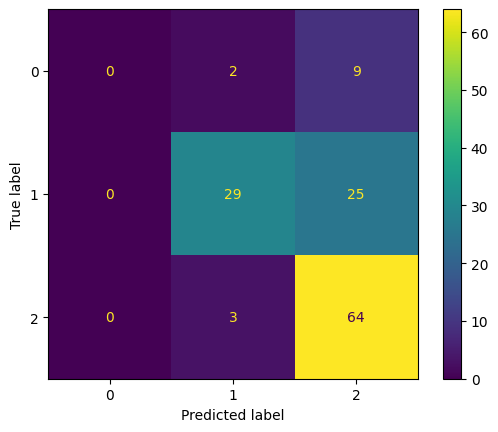

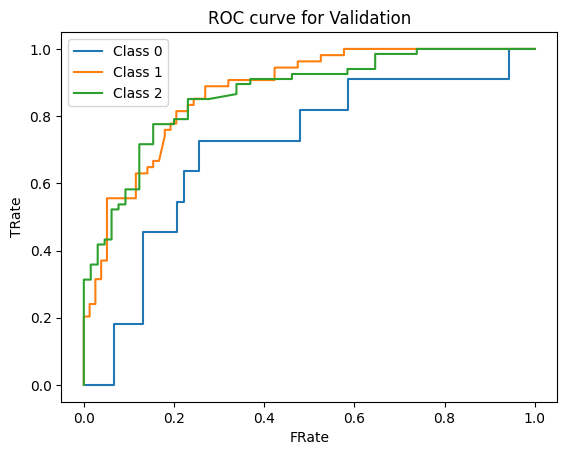


AUC Validation Metric:  0.8166147226725876


In [ ]:
####@@@-- Validation -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXavl)
dimenrdcpr = Dimenredmd.predict(DimenRedctXavl)
print(Dimen_Reductrpt(DimenRedctYavl, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nValidate Time--LR Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYavl, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()


DimenRedctYavl_bin = Dimen_Reductlb(DimenRedctYavl, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
dimen_clas = DimenRedctYavl_bin.shape[1]

for d in range(dimen_clas):
    dimfp, dimtp, dimth = Dimen_Reductmcs.roc_curve(DimenRedctYavl_bin[:, d], dimenrdcpr_probs[:, d])
    Dimen_ReductMn.plot(dimfp, dimtp, label=f'Class {Dimenredmd.classes_[d]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Validation')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYavl, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Validation Metric: ", DimenRedtAuc)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.77      0.38      0.51        52
           2       0.61      0.98      0.75        66

    accuracy                           0.64       133
   macro avg       0.46      0.46      0.42       133
weighted avg       0.60      0.64      0.57       133


Test Time--LR Classifier : 0.01773524284362793 



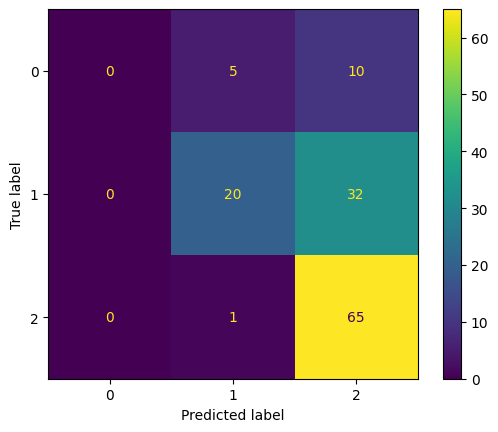

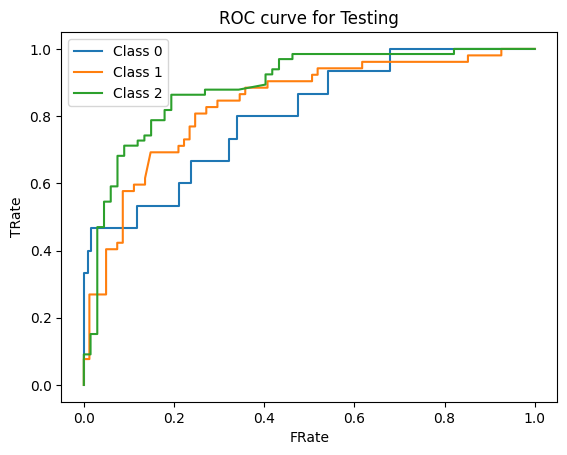


AUC Testing Metric:  0.8424610587974559


In [ ]:
####@@@-- Testing -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXatst)
dimenrdcpr = Dimenredmd.predict(DimenRedctXatst)
print(Dimen_Reductrpt(DimenRedctYatst, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nTest Time--LR Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYatst, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()


DimenRedctYatst_bin = Dimen_Reductlb(DimenRedctYatst, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
dimen_clas = DimenRedctYatst_bin.shape[1]

###@@@--- Calculate ROC curve for each class
for d in range(dimen_clas):
    dimfp, dimtp, dimth = Dimen_Reductmcs.roc_curve(DimenRedctYatst_bin[:, d], dimenrdcpr_probs[:, d])
    Dimen_ReductMn.plot(dimfp, dimtp, label=f'Class {Dimenredmd.classes_[d]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Testing')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYatst, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Testing Metric: ", DimenRedtAuc)

#Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier as Dimen_ReductDTC

Dimen_Reducthyprms = {
                       'criterion' : ['gini', 'entropy', 'log_loss'],
                       'splitter' : ['best', 'random'],
                       'max_depth' : [1, 5, 10, 50, None]
                       }

Dimenredmd = Dimen_ReductDTC()
Dimenredmd = Dimen_Reductgrdsh(Dimenredmd,Dimen_Reducthyprms, cv=2)
Dimenredmd.fit(DimenRedctXatrn[:400], DimenRedctYatrn[:400])
print("best Params -- DT:")
print(Dimenredmd.best_params_)

best Params -- DT:
{'criterion': 'log_loss', 'max_depth': None, 'splitter': 'random'}


In [ ]:
####@@@-- Training -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
Dimenredmd = Dimen_ReductDTC(**Dimenredmd.best_params_)
Dimenredmd.fit(DimenRedctXatrn, DimenRedctYatrn)
dimenrednd2 = Dimen_Reductm.time()
print("\nTrain Time--DT classifier   :", dimenrednd2-dimenrednd1,"\n")


Train Time--DT classifier   : 1.618894338607788 



              precision    recall  f1-score   support

           0       0.25      0.18      0.21        11
           1       0.65      0.78      0.71        54
           2       0.78      0.69      0.73        67

    accuracy                           0.68       132
   macro avg       0.56      0.55      0.55       132
weighted avg       0.68      0.68      0.68       132


Validate Time--DT Classifier : 0.011301279067993164 



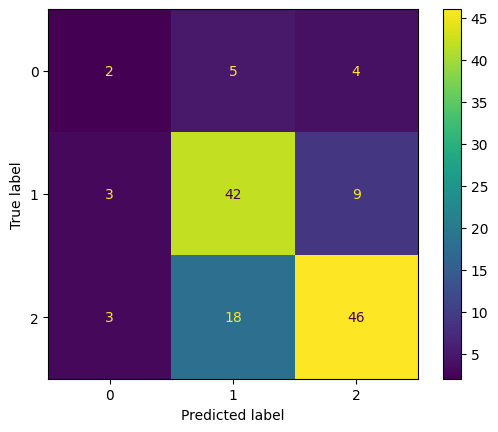

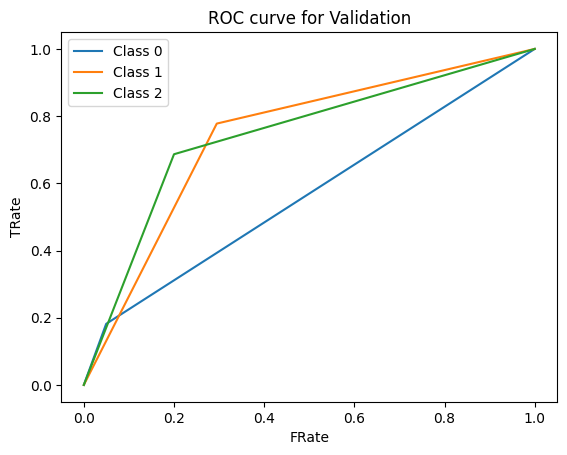


AUC Validation Metric:  0.6836174253406275


In [ ]:
####@@@-- Validation -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXavl)
dimenrdcpr = Dimenredmd.predict(DimenRedctXavl)
print(Dimen_Reductrpt(DimenRedctYavl, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nValidate Time--DT Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYavl, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()


DimenRedctYavl_bin = Dimen_Reductlb(DimenRedctYavl, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
dimen_clas = DimenRedctYavl_bin.shape[1]

for d in range(dimen_clas):
    dimfp, dimtp, dimth = Dimen_Reductmcs.roc_curve(DimenRedctYavl_bin[:, d], dimenrdcpr_probs[:, d])
    Dimen_ReductMn.plot(dimfp, dimtp, label=f'Class {Dimenredmd.classes_[d]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Validation')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYavl, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Validation Metric: ", DimenRedtAuc)

              precision    recall  f1-score   support

           0       0.50      0.33      0.40        15
           1       0.56      0.63      0.59        52
           2       0.72      0.70      0.71        66

    accuracy                           0.63       133
   macro avg       0.59      0.55      0.57       133
weighted avg       0.63      0.63      0.63       133


Test Time--DT Classifier : 0.016555070877075195 



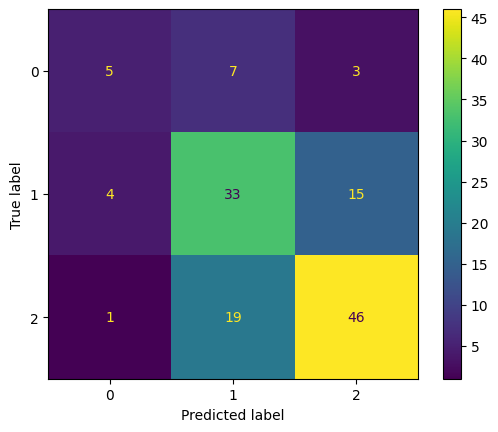

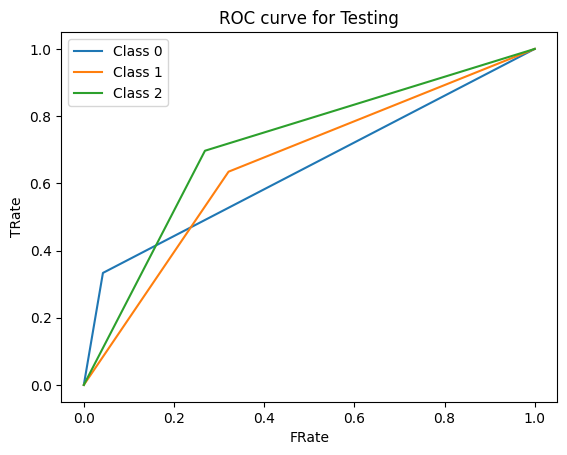


AUC Testing Metric:  0.6721501938039308


In [ ]:
####@@@-- Testing -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXatst)
dimenrdcpr = Dimenredmd.predict(DimenRedctXatst)
print(Dimen_Reductrpt(DimenRedctYatst, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nTest Time--DT Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYatst, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()


DimenRedctYatst_bin = Dimen_Reductlb(DimenRedctYatst, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
dimen_clas = DimenRedctYatst_bin.shape[1]

###@@@--- Calculate ROC curve for each class
for d in range(dimen_clas):
    dimfp, dimtp, dimth = Dimen_Reductmcs.roc_curve(DimenRedctYatst_bin[:, d], dimenrdcpr_probs[:, d])
    Dimen_ReductMn.plot(dimfp, dimtp, label=f'Class {Dimenredmd.classes_[d]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Testing')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYatst, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Testing Metric: ", DimenRedtAuc)

#Balanced Random Forest Classifier

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier as Dimen_ReductBRF


Dimen_Reducthyprms = {
                       'n_estimators' : [10, 50, 100, 200],
                       'criterion' : ['gini', 'entropy', 'log_loss'],
                       'max_depth' : [1, 5, 50, None],
                       'max_features': [None, 'sqrt', 'log2']
                       }

Dimenredmd = Dimen_ReductBRF()
Dimenredmd = Dimen_Reductgrdsh(Dimenredmd,Dimen_Reducthyprms, cv=2)
Dimenredmd.fit(DimenRedctXatrn[:400], DimenRedctYatrn[:400])
print("best Params -- BRF:")
print(Dimenredmd.best_params_)

best Params -- BRF:
{'criterion': 'entropy', 'max_depth': 1, 'max_features': 'log2', 'n_estimators': 10}


In [ ]:
####@@@-- Training -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
Dimenredmd = Dimen_ReductBRF(**Dimenredmd.best_params_)
Dimenredmd.fit(DimenRedctXatrn, DimenRedctYatrn)
dimenrednd2 = Dimen_Reductm.time()
print("\nTrain Time--BRF classifier   :", dimenrednd2-dimenrednd1,"\n")


Train Time--BRF classifier   : 0.05983471870422363 



              precision    recall  f1-score   support

           0       0.09      1.00      0.16        11
           1       0.00      0.00      0.00        54
           2       1.00      0.04      0.09        67

    accuracy                           0.11       132
   macro avg       0.36      0.35      0.08       132
weighted avg       0.51      0.11      0.06       132


Validate Time--BRF Classifier : 0.016065597534179688 



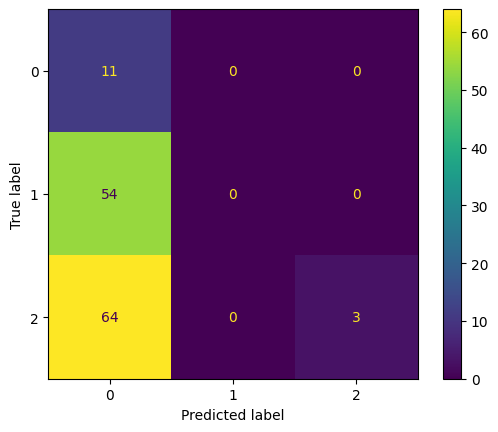

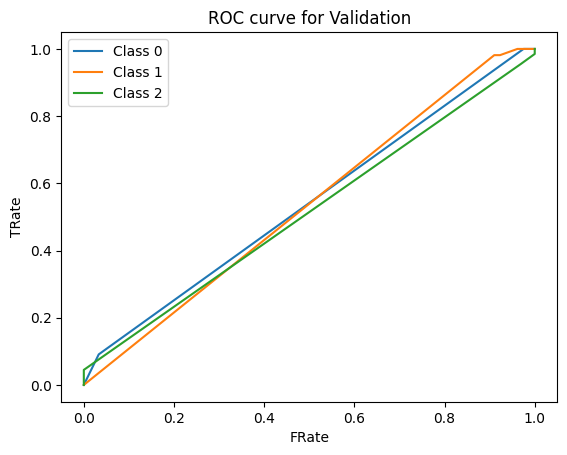


AUC Validation Metric:  0.530170475082965


In [ ]:
####@@@-- Validation -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXavl)
dimenrdcpr = Dimenredmd.predict(DimenRedctXavl)
print(Dimen_Reductrpt(DimenRedctYavl, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nValidate Time--BRF Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYavl, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()


DimenRedctYavl_bin = Dimen_Reductlb(DimenRedctYavl, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
dimen_clas = DimenRedctYavl_bin.shape[1]

for d in range(dimen_clas):
    dimfp, dimtp, dimth = Dimen_Reductmcs.roc_curve(DimenRedctYavl_bin[:, d], dimenrdcpr_probs[:, d])
    Dimen_ReductMn.plot(dimfp, dimtp, label=f'Class {Dimenredmd.classes_[d]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Validation')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYavl, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Validation Metric: ", DimenRedtAuc)

              precision    recall  f1-score   support

           0       0.12      1.00      0.21        15
           1       0.00      0.00      0.00        52
           2       1.00      0.06      0.11        66

    accuracy                           0.14       133
   macro avg       0.37      0.35      0.11       133
weighted avg       0.51      0.14      0.08       133


Test Time--BRF Classifier : 0.020224809646606445 



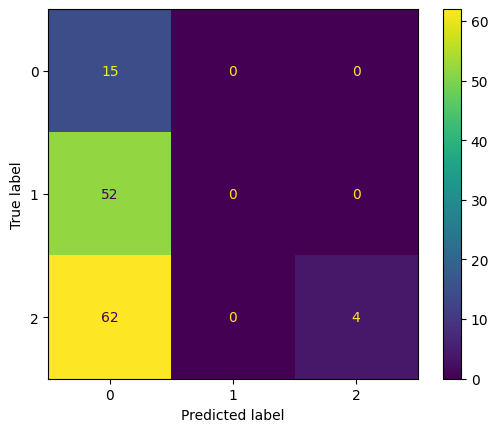

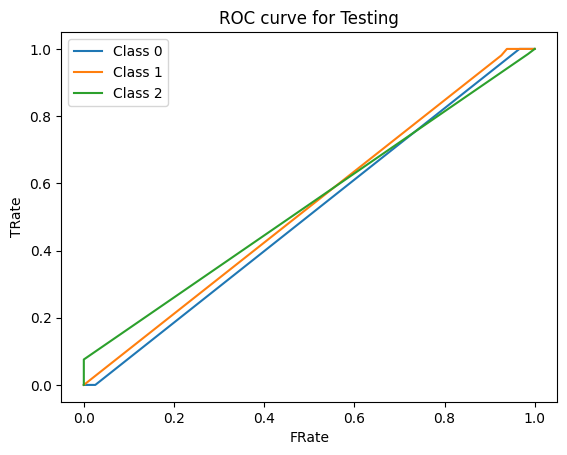


AUC Testing Metric:  0.523150948214894


In [ ]:
####@@@-- Testing -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXatst)
dimenrdcpr = Dimenredmd.predict(DimenRedctXatst)
print(Dimen_Reductrpt(DimenRedctYatst, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nTest Time--BRF Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYatst, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()

DimenRedctYatst_bin = Dimen_Reductlb(DimenRedctYatst, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
dimen_clas = DimenRedctYatst_bin.shape[1]

###@@@--- Calculate ROC curve for each class
for d in range(dimen_clas):
    dimfp, dimtp, dimth = Dimen_Reductmcs.roc_curve(DimenRedctYatst_bin[:, d], dimenrdcpr_probs[:, d])
    Dimen_ReductMn.plot(dimfp, dimtp, label=f'Class {Dimenredmd.classes_[d]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Testing')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()


DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYatst, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Testing Metric: ", DimenRedtAuc)